In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import cv2
from skimage import exposure, filters, color
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

print(" OpenCV     :", cv2.__version__)
print(" TensorFlow :", tf.__version__)
print(" NumPy      :", np.__version__)
print(" GPU        :", tf.config.list_physical_devices('GPU'))

2026-04-04 05:29:45.017124: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775280585.435757      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775280585.551692      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775280586.526603      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775280586.526648      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775280586.526651      24 computation_placer.cc:177] computation placer alr

 OpenCV     : 4.13.0
 TensorFlow : 2.19.0
 NumPy      : 2.0.2
 GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
DATA_DIR = "/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color"
classes = sorted(os.listdir(DATA_DIR))
print(f" Classes found: {len(classes)}")

 Classes found: 38


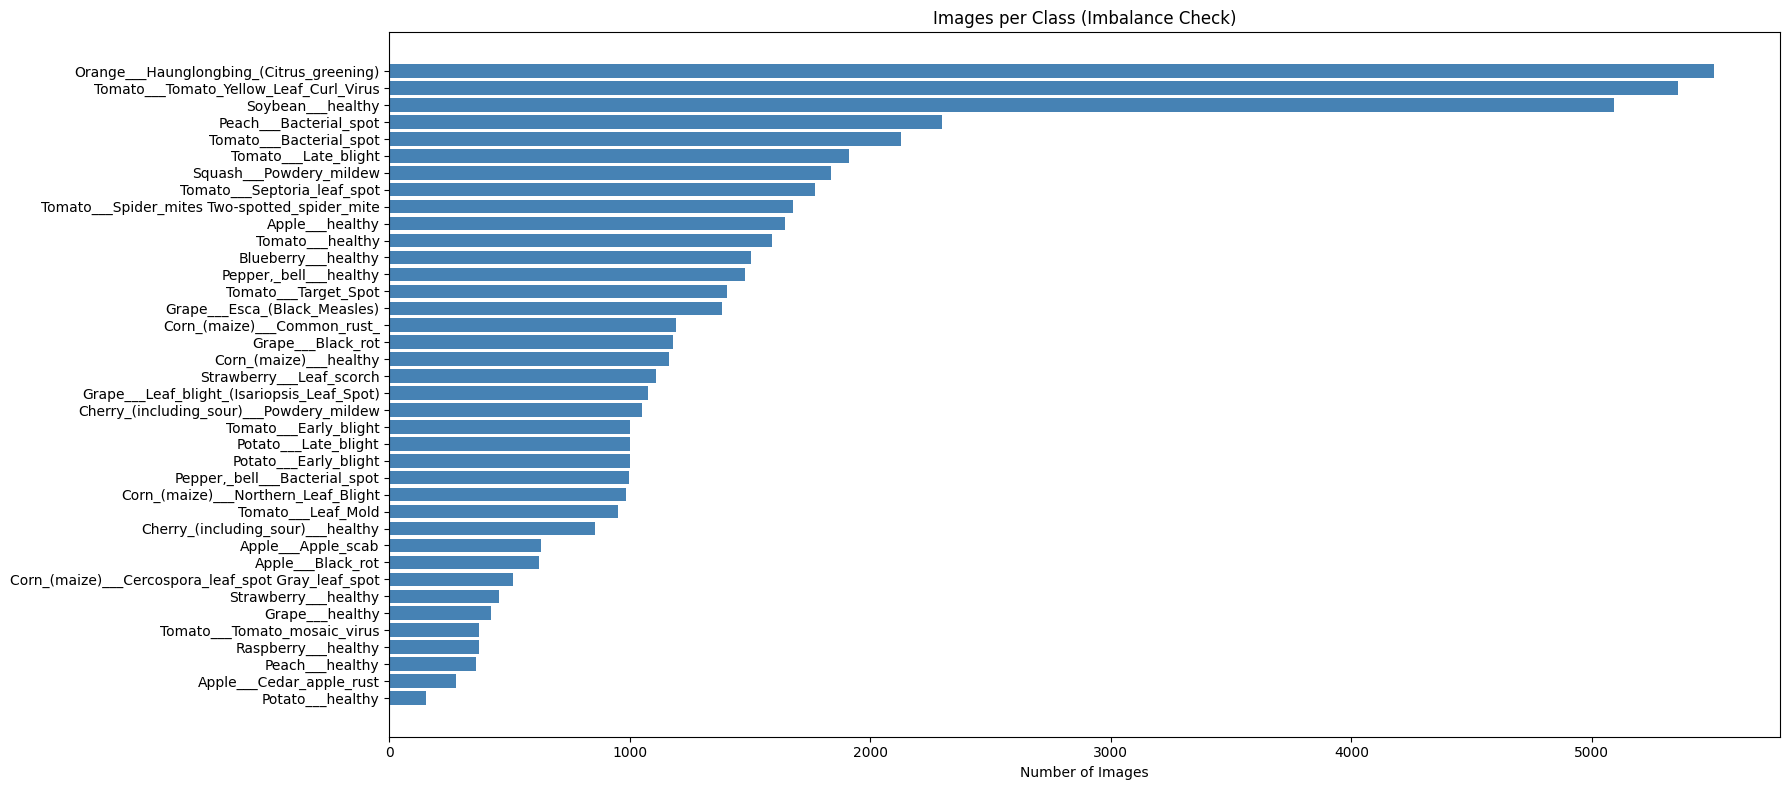

Max images in a class : 5507
Min images in a class : 152
Average per class     : 1429
Total images          : 54305


In [3]:
class_counts = {}
for class_name in classes:
    class_path = os.path.join(DATA_DIR, class_name)
    count = len(os.listdir(class_path))
    class_counts[class_name] = count

class_counts = dict(sorted(class_counts.items(), key=lambda x: x[1]))

plt.figure(figsize=(18, 8))
plt.barh(list(class_counts.keys()), list(class_counts.values()), color='steelblue')
plt.xlabel("Number of Images")
plt.title("Images per Class (Imbalance Check)")
plt.tight_layout()
plt.show()

counts = list(class_counts.values())
print(f"Max images in a class : {max(counts)}")
print(f"Min images in a class : {min(counts)}")
print(f"Average per class     : {int(sum(counts)/len(counts))}")
print(f"Total images          : {sum(counts)}")

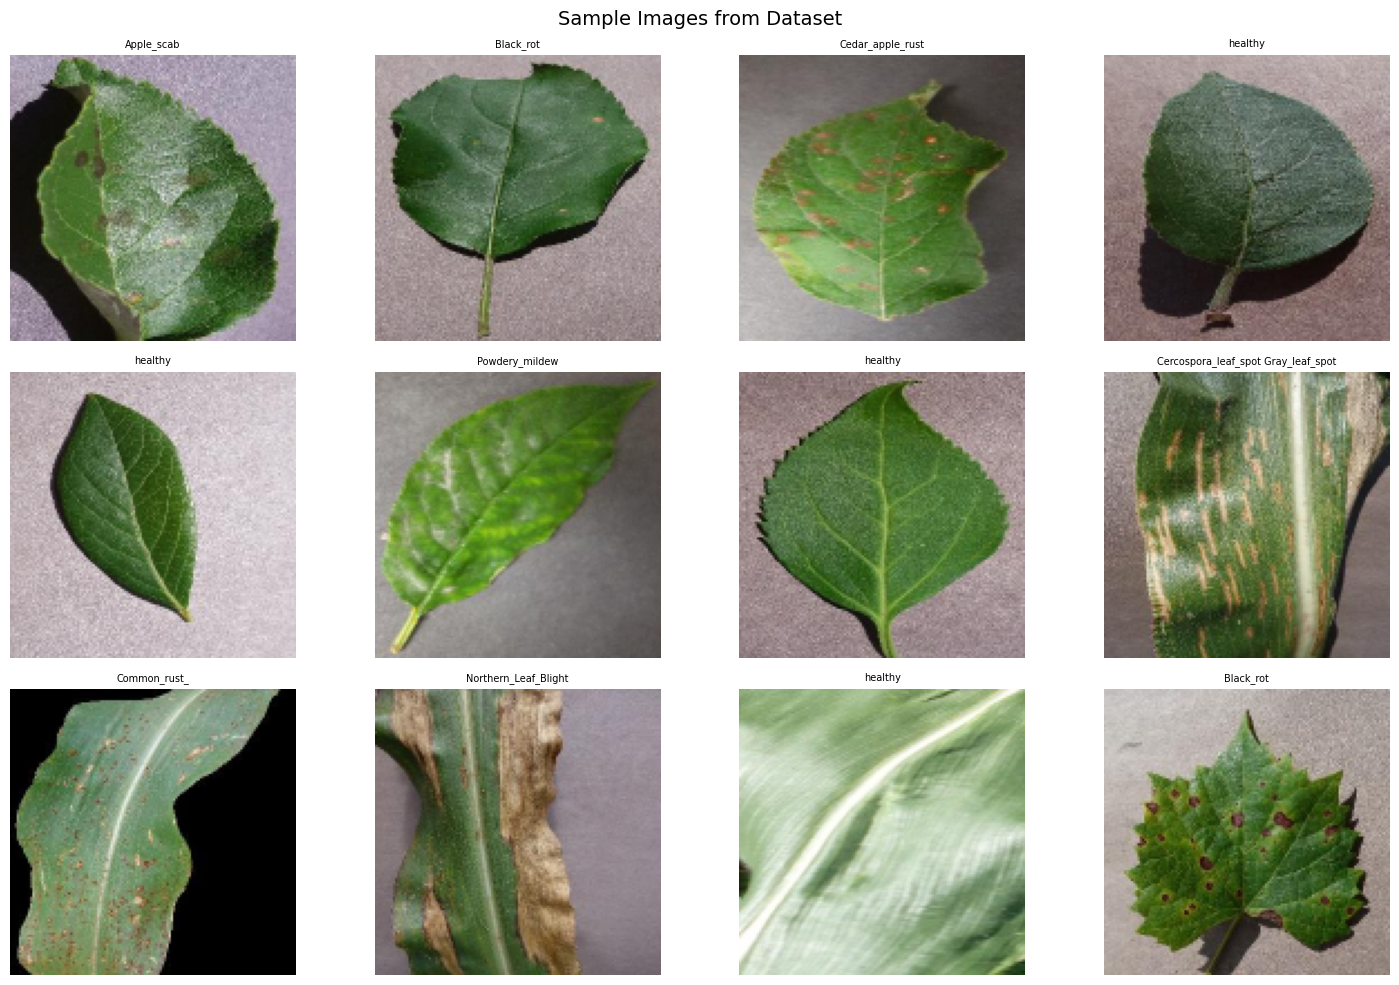

In [4]:
plt.figure(figsize=(15, 10))
sample_classes = classes[:12]
for i, class_name in enumerate(sample_classes):
    class_path = os.path.join(DATA_DIR, class_name)
    img_file = os.listdir(class_path)[0]
    img = cv2.imread(os.path.join(class_path, img_file))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (128, 128))
    plt.subplot(3, 4, i+1)
    plt.imshow(img_resized)
    plt.title(class_name.split("___")[1], fontsize=7)
    plt.axis("off")
plt.suptitle("Sample Images from Dataset", fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
all_labels = []
for idx, class_name in enumerate(classes):
    class_path = os.path.join(DATA_DIR, class_name)
    count = len(os.listdir(class_path))
    all_labels.extend([idx] * count)

all_labels = np.array(all_labels)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels
)
class_weight_dict = dict(enumerate(class_weights))
print(" Class weights computed!")

 Class weights computed!


In [6]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

# Split val into val + test
val_batches = len(val_ds)
test_size   = val_batches // 2
test_ds     = val_ds.take(test_size)
val_ds      = val_ds.skip(test_size)

print(f" Classes : {len(class_names)}")
print(f" Train   : {len(train_ds)} batches")
print(f" Val     : {len(val_ds)} batches")
print(f" Test    : {len(test_ds)} batches")

Found 54305 files belonging to 38 classes.
Using 43444 files for training.


I0000 00:00:1775280678.334401      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775280678.340799      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 54305 files belonging to 38 classes.
Using 10861 files for validation.
 Classes : 38
 Train   : 1358 batches
 Val     : 170 batches
 Test    : 170 batches


In [7]:
AUTOTUNE = tf.data.AUTOTUNE

augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
])

def preprocess(images, labels):
    images = tf.cast(images, tf.float32) / 255.0
    return images, labels

train_ds = train_ds.map(lambda x, y: (augmentation(x, training=True), y))
train_ds = train_ds.map(preprocess).cache().prefetch(AUTOTUNE)
val_ds   = val_ds.map(preprocess).cache().prefetch(AUTOTUNE)
test_ds  = test_ds.map(preprocess).cache().prefetch(AUTOTUNE)

print(" Augmentation done!")

 Augmentation done!


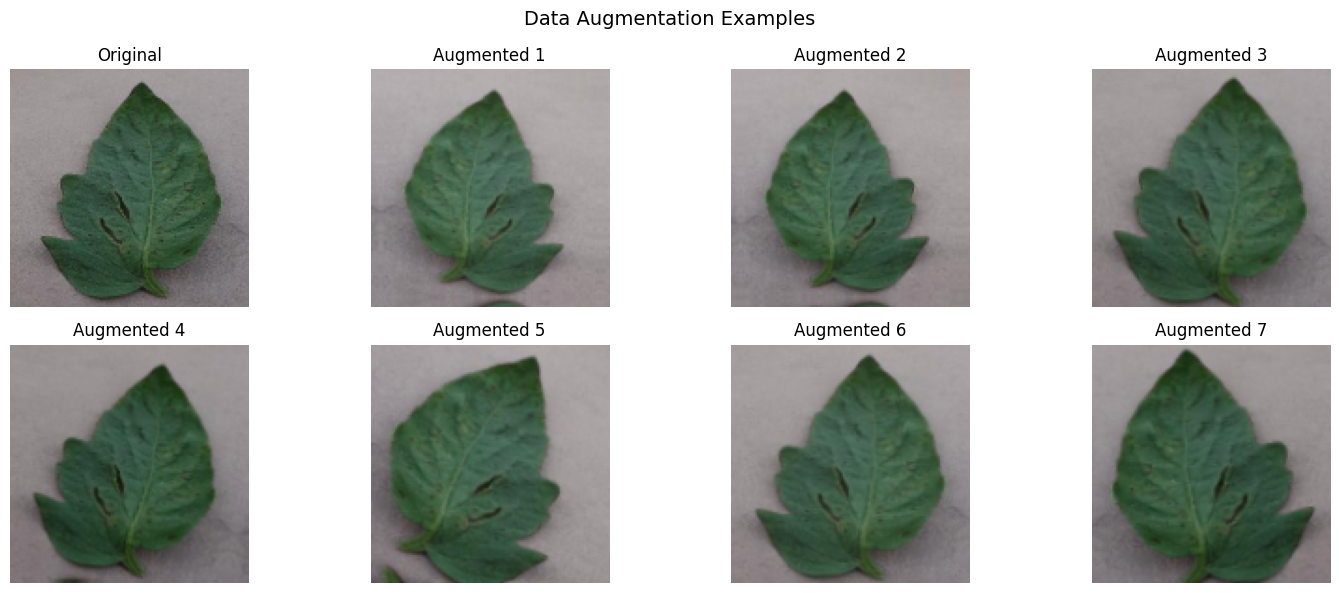

In [8]:
sample_class = classes[28]
sample_path = os.path.join(DATA_DIR, sample_class)
img_file = os.listdir(sample_path)[0]
img = cv2.imread(os.path.join(sample_path, img_file))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (128, 128))
img_tensor = tf.cast(img_resized, tf.float32)

plt.figure(figsize=(15, 6))
plt.subplot(2, 4, 1)
plt.imshow(img_resized)
plt.title("Original")
plt.axis("off")

for i in range(1, 8):
    aug_img = augmentation(tf.expand_dims(img_tensor, 0), training=True)
    aug_img = (aug_img[0].numpy() / 255.0).clip(0, 1)
    plt.subplot(2, 4, i+1)
    plt.imshow(aug_img)
    plt.title(f"Augmented {i}")
    plt.axis("off")

plt.suptitle("Data Augmentation Examples", fontsize=14)
plt.tight_layout()
plt.show()